In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('smoking_health_data_final.csv')
df.head()

,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol
0,54,male,yes,95,110/72,NaN,219.0
1,45,male,yes,64,121/72,NaN,248.0
2,58,male,yes,81,127.5/76,NaN,235.0
3,42,male,yes,90,122.5/80,NaN,225.0
4,42,male,yes,62,119/80,NaN,226.0


#### Applying `pivot_table`

A Pivot Table is simply a tool that takes a massive, unreadable list of raw data and "spins" it into a tiny, clean, highly-readable summary grid.

It answers the question: "How can I cross-reference two different categories to find the average/sum?"

### `pd.pivot_table()` Parameters Cheat Sheet

| Parameter | Required? | What it does | Example / Options |
| :--- | :---: | :--- | :--- |
| **`data`** | Yes | The raw dataframe you want to compress. | `data=df` |
| **`index`** | Yes | The column(s) you want running down the **LEFT** side as Rows. | `index='Store_Location'` |
| **`columns`** | No | The column(s) you want running across the **TOP** as Headers. | `columns='Date'` |
| **`values`** | No | The specific column of numbers you want to do math on *inside* the cells. If left blank, Pandas tries to do math on every numeric column! | `values='Daily_Revenue'` |
| **`aggfunc`** | No | The mathematical rule for how to smash the numbers together. Defaults to `'mean'`. | `'mean'`, `'sum'`, `'count'`, `'max'`, `'min'`, or `['sum', 'mean']` |
| **`fill_value`** | No | What to put in cells where no data exists. Replaces `NaN` with a value of your choice. | `fill_value=0` |
| **`margins`** | No | If `True`, adds a "Grand Total" row at the bottom and a "Grand Total" column at the far right. Defaults to `False`. | `margins=True` |
| **`margins_name`** | No | What to name the Grand Total row/column if `margins=True` is turned on. Defaults to the word `"All"`. | `margins_name='Total'` |
| **`dropna`** | No | If `True`, it deletes any columns/rows where every single cell is completely blank. Defaults to `True` to keep tables clean. | `dropna=True` |



### Basic Usage Example:
If you want to know the **Total Revenue** for each **Store Location**, broken down by **Date**:

**`pd.pivot_table(data=df, index='Store_Location', columns='Date', values='Daily_Revenue', aggfunc='sum')`**


In [3]:
pd.pivot_table(df, index='age', columns='current_smoker', values='cigs_per_day', aggfunc='mean')

current_smoker,no,yes
age,,
32,NaN,15.000000
33,0.0,10.000000
34,0.0,15.555556
35,0.0,16.608696
36,0.0,18.911111
37,0.0,20.388889
38,0.0,16.728395
39,0.0,19.744444
40,0.0,19.772727


In [4]:
print(df.columns)
df.info()

Index(['age', 'sex', 'current_smoker', 'heart_rate', 'blood_pressure',
       'cigs_per_day', 'chol'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             3900 non-null   int64  
 1   sex             3900 non-null   object 
 2   current_smoker  3900 non-null   object 
 3   heart_rate      3900 non-null   int64  
 4   blood_pressure  3900 non-null   object 
 5   cigs_per_day    3886 non-null   float64
 6   chol            3893 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 213.4+ KB


In [5]:
# what age group of ppl consume more cigrates, and what gender consumes more cigrattes
pd.pivot_table(df, index='age', columns='sex', values='cigs_per_day', aggfunc='mean')

sex,female,male
age,,
32,15.000000,NaN
33,6.666667,0.000000
34,7.272727,12.000000
35,6.200000,15.176471
36,8.270270,12.674419
37,10.930233,14.674419
38,7.303030,12.652174
39,7.085366,16.611111
40,7.861702,17.950000


In [6]:
# what age group of ppl consume more cigrates, and what gender consumes more cigrattes
pd.pivot_table(df, index='age', columns='sex', values='cigs_per_day', aggfunc=['max', 'mean'])

max             mean           
sex female  male     female       male
age                                   
32    15.0   NaN  15.000000        NaN
33    15.0   0.0   6.666667   0.000000
34    20.0  25.0   7.272727  12.000000
35    30.0  40.0   6.200000  15.176471
36    43.0  40.0   8.270270  12.674419
37    43.0  60.0  10.930233  14.674419
38    35.0  50.0   7.303030  12.652174
39    30.0  60.0   7.085366  16.611111
40    43.0  70.0   7.861702  17.950000
41    43.0  43.0   6.538462  15.881579
42    30.0  43.0   8.064516  15.800000
43    30.0  45.0   8.855263  18.228571
44    30.0  43.0   7.268657  15.069767
45    30.0  43.0   6.756410  13.458333
46    43.0  60.0   7.735849  16.985075
47    43.0  50.0   8.837838  15.500000
48    35.0  60.0   5.289474  13.964286
49    30.0  60.0   4.294118  15.480769
50    30.0  60.0   7.441176  14.136364
51    25.0  50.0   4.739726  14.338710
52    30.0  35.0   4.500000  10.014286
53    40.0  50.0   4.784615  14.090909
54    20.0  43.0   2.671429  14.735849
55    35.0  45.0   2.411765  11.916667
56    40.0  60.0   4.672131  11.754717
57    43.0  43.0   4.196429   9.421053
58    30.0  60.0   3.607843  11.183673
59    35.0  60.0   3.278689  12.954545
60    20.0  40.0   2.666667   8.254902
61    30.0  30.0   3.379310   7.046512
62    20.0  43.0   1.212766  10.152174
63    40.0  43.0   2.516129  10.951220
64    30.0  40.0   2.584906   6.942857
65     9.0  25.0   0.433333   5.476190
66    20.0  30.0   1.650000   6.500000
67    20.0  60.0   2.043478  10.352941
68    20.0  15.0  10.000000   4.166667
69     0.0  23.0   0.000000   9.333333
70     0.0   NaN   0.000000        NaN

### learning to replace texts in data frame

In [7]:
df.head()

,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol
0,54,male,yes,95,110/72,NaN,219.0
1,45,male,yes,64,121/72,NaN,248.0
2,58,male,yes,81,127.5/76,NaN,235.0
3,42,male,yes,90,122.5/80,NaN,225.0
4,42,male,yes,62,119/80,NaN,226.0


In [8]:
print(df['sex'].unique())

a = df['sex'].copy()
a = a.str.lower().str.replace('male', 'MARD').str.replace('female', 'AURAT')
a

['male' 'female']


0       MARD
1       MARD
2       MARD
3       MARD
4       MARD
        ... 
3895    MARD
3896    MARD
3897    MARD
3898    MARD
3899    MARD
Name: sex, Length: 3900, dtype: object

In [9]:
print(a.unique())       # the reason you got feMARD bcoz ".str" never reads the text like words, it reads the text like letters
# for eg it will not read it like "male", but rather it will read it like 'm-a-l-e' as separate letters, and if the letters are in same sequence as the same as target word set in ".replace", then it will do the work


['MARD' 'feMARD']


In [10]:
a = df['sex'].copy()

a = a.map({
    'male':'MARD',
    'female':'AURAT'
})

print(a.unique())
a.sample(5)

['MARD' 'AURAT']


1036    AURAT
3396    AURAT
3582     MARD
3403    AURAT
1058    AURAT
Name: sex, dtype: object

### Using `np.where`

# Pandas Mastery: Series vs. DataFrame

In Pandas, knowing whether you are working with a **Series** or a **DataFrame** is crucial. This determines which methods you can use (e.g., `.columns` only works on DataFrames, while `.unique()` is primarily a Series method).

---

## 1. The Core Definition
* **DataFrame**: A 2-dimensional table (Rows and Columns).
* **Series**: A 1-dimensional array (A single column).



---

## 2. Selection Logic: The "Brackets Rule"
The easiest way to control your output is by how you use brackets `[]`.

##### Single Brackets `[]` $\rightarrow$ Series
##### Doubt Brackets `[[]]` $\rightarrow$ DataFrame


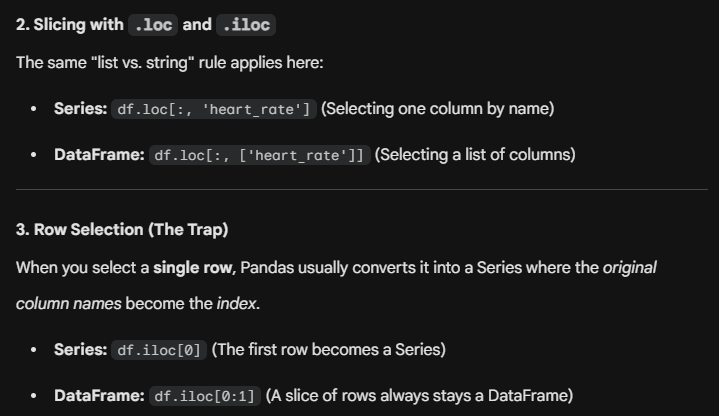

In [11]:
df.sample(6)

,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol
2907,61,male,yes,75,156/92,20.0,183.0
775,60,female,no,85,152.5/85,0.0,232.0
508,55,female,no,110,135/76.5,0.0,310.0
552,55,female,no,58,172.5/100.5,0.0,260.0
2854,37,male,yes,100,142/80,20.0,205.0
1904,61,female,no,80,194/111,0.0,225.0


In [12]:
def change(df):
    df = np.where(df >= 50, '> 50', '<50')

    df = pd.DataFrame(df)

    return df

In [13]:
a = change(df[['heart_rate']])
# a = change(df['heart_rate'])

print(a[0].unique())
a

['> 50' '<50']


,0
0,> 50
1,> 50
2,> 50
3,> 50
4,> 50
...,...
3895,> 50
3896,> 50
3897,> 50
3898,> 50


In [14]:
df['heart_rate']

0       95
1       64
2       81
3       90
4       62
        ..
3895    88
3896    70
3897    70
3898    85
3899    98
Name: heart_rate, Length: 3900, dtype: int64

### Using `df.groupby()`

In [15]:
df.columns

Index(['age', 'sex', 'current_smoker', 'heart_rate', 'blood_pressure',
       'cigs_per_day', 'chol'],
      dtype='object')

In [16]:
df.groupby('sex')['cigs_per_day'].mean()

sex
female     5.527631
male      13.366205
Name: cigs_per_day, dtype: float64

## `groupby()` vs. `pivot_table()`: The Ultimate Guide

In Pandas, both `.groupby()` and `.pivot_table()` are used to compress raw data into summaries using math (like `sum` or `mean`). In fact, under the hood, a `pivot_table` is literally just a `groupby` with extra formatting! 

Here is exactly how to know which one to use.

---

#### 1. The Core Difference: The Shape of the Output

The biggest difference between them is **how they format the final table**.

*   **`groupby()` is 1-Dimensional (Vertical):** It groups things into a long, vertical list. If you group by two categories, it stacks them on top of each other in the index (creating a MultiIndex).
*   **`pivot_table()` is 2-Dimensional (A Grid):** It groups things into a wide, Excel-style matrix. It takes one category and puts it on the Left (Rows), and takes the second category and puts it on the Top (Columns).

---

#### 2. When to use which?

**Use `.groupby()` when:**
*   You only want to group by **one** category (e.g., "Total sales by City").
*   You want the code to run slightly faster (it has less formatting overhead).
*   You are chaining commands together (like `.groupby().max().sort_values()`).

**Use `.pivot_table()` when:**
*   You are grouping by **two** categories and want to cross-reference them (e.g., "Sales by City AND by Day of the week").
*   You want an easy-to-read, beautifully formatted 2D table to show a boss or client.
*   You want to easily handle missing data using `fill_value=0`.

---

#### 3. Visual Example

Imagine a raw dataframe of clothing sales: `['Gender', 'Item', 'Revenue']`. We want to know the total revenue for Shirts vs. Pants, broken down by Men vs. Women.

###### The `groupby()` Approach (Vertical)
```python
df.groupby(['Gender', 'Item'])['Revenue'].sum()


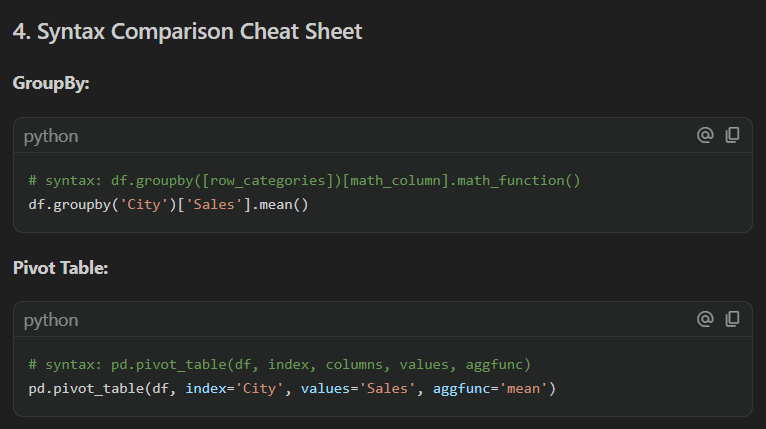

### Using multi level category in `pivot_table()`



```python

# Put BOTH 'Gender' and 'Item' on the Rows
pd.pivot_table(
    df, 
    index=['Gender', 'Item'], 
    values='Revenue', 
    aggfunc='sum'
)
```


In [17]:
df.columns

Index(['age', 'sex', 'current_smoker', 'heart_rate', 'blood_pressure',
       'cigs_per_day', 'chol'],
      dtype='object')

##### One Category

In [27]:
df.pivot_table(index='sex', columns='cigs_per_day', values='heart_rate', aggfunc='mean')

cigs_per_day,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,29.0,30.0,35.0,38.0,40.0,43.0,45.0,50.0,60.0,70.0
sex,,,,,,,,,,,,,,,,,,,,,
female,76.581340,77.489796,77.833333,73.450000,80.833333,75.947368,79.375000,74.666667,78.571429,77.652778,...,NaN,74.775000,73.750000,NaN,84.375000,85.5,NaN,NaN,NaN,NaN
male,72.243697,71.750000,75.200000,71.793103,68.333333,71.034483,72.111111,73.400000,66.000000,73.222222,...,77.0,76.464286,72.352941,75.0,76.971014,80.6,74.333333,74.8,73.545455,98.0


##### Multi Category

In [ ]:
df.pivot_table(index=['sex','current_smoker'], columns='cigs_per_day', values='heart_rate', aggfunc='mean')

cigs_per_day                0.0        1.0        2.0        3.0        4.0   \
sex    current_smoker                                                          
female no              76.581340        NaN        NaN        NaN        NaN   
       yes                   NaN  77.489796  77.833333  73.450000  80.833333   
male   no              72.243697        NaN        NaN        NaN        NaN   
       yes                   NaN  71.750000  75.200000  71.793103  68.333333   

cigs_per_day                5.0        6.0        7.0        8.0        9.0   \
sex    current_smoker                                                          
female no                    NaN        NaN        NaN        NaN        NaN   
       yes             75.947368  79.375000  74.666667  78.571429  77.652778   
male   no                    NaN        NaN        NaN        NaN        NaN   
       yes             71.034483  72.111111  73.400000  66.000000  73.222222   

cigs_per_day           ...  29.0       30.0       35.0  38.0       40.0  43.0  \
sex    current_smoker  ...                                                      
female no              ...   NaN        NaN        NaN   NaN        NaN   NaN   
       yes             ...   NaN  74.775000  73.750000   NaN  84.375000  85.5   
male   no              ...   NaN        NaN        NaN   NaN        NaN   NaN   
       yes             ...  77.0  76.464286  72.352941  75.0  76.971014  80.6   

cigs_per_day                45.0  50.0       60.0  70.0  
sex    current_smoker                                    
female no                    NaN   NaN        NaN   NaN  
       yes                   NaN   NaN        NaN   NaN  
male   no                    NaN   NaN        NaN   NaN  
       yes             74.333333  74.8  73.545455  98.0  

[4 rows x 33 columns]

In [30]:
df.pivot_table(index=['sex','current_smoker'], columns=['cigs_per_day','chol'], values='heart_rate', aggfunc='mean')

cigs_per_day           0.0                                                    \
chol                  124.0 126.0 135.0 137.0 144.0 145.0 148.0  149.0 150.0   
sex    current_smoker                                                          
female no               NaN   NaN  70.0   NaN  72.0  90.0   NaN    NaN  72.0   
       yes              NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   
male   no              75.0  86.0   NaN  60.0   NaN   NaN  75.0  105.0  64.0   
       yes              NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   

cigs_per_day                 ...  60.0                                      \
chol                  152.0  ... 232.0 246.0 250.0 252.0 254.0 261.0 285.0   
sex    current_smoker        ...                                             
female no              67.5  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
       yes              NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
male   no              77.0  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
       yes              NaN  ...  80.0  70.0  75.0  70.0  88.0  72.0  70.0   

cigs_per_day                       70.0  
chol                  298.0 340.0 210.0  
sex    current_smoker                    
female no               NaN   NaN   NaN  
       yes              NaN   NaN   NaN  
male   no               NaN   NaN   NaN  
       yes             70.0  85.0  98.0  

[4 rows x 1243 columns]

In [41]:
df.groupby('sex')['heart_rate'].mean()

sex
female    76.940413
male      74.257284
Name: heart_rate, dtype: float64

---

### Using `.map()` function

In [42]:
df.sample(6)

,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol
2394,64,female,yes,73,145/79,9.0,250.0
1346,48,female,no,72,144/90,0.0,234.0
3215,58,male,yes,72,129/82,20.0,220.0
3303,65,male,yes,98,140/82.5,20.0,285.0
345,66,male,no,85,151/88,0.0,182.0
2846,53,male,yes,64,120/80,20.0,260.0


In [45]:
a = df['sex'].map({
    'male':'MARD',
    'female':'AURAT'
})

a.sample(6)

1050     MARD
295     AURAT
1510     MARD
200      MARD
2233    AURAT
560      MARD
Name: sex, dtype: object

In [51]:
df.groupby('current_smoker')['age'].mean()

current_smoker
no     51.381098
yes    47.660455
Name: age, dtype: float64

In [ ]:
df.pivot_table(index='current_smoker', columns='sex', values='age')

sex,female,male
current_smoker,,
no,51.641148,50.924370
yes,46.904474,48.226244
